<a href="https://colab.research.google.com/github/Kevin-Lucey/Algorithms/blob/main/Lucey_W5HW_LinearRegresseion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [6]:
from sklearn.datasets import fetch_openml

# Load dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)
print(boston)
# Features and target
X = boston.data
y = boston.target

# View dataset
print(X.head())
print(y.head())

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

<class 'sklearn.utils._bunch.Bunch'>
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64
Shape of X: (506, 13)
Shape of y: (506,)


In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [7]:
# Rename variables
df = pd.DataFrame(X)
df['target'] = y



,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


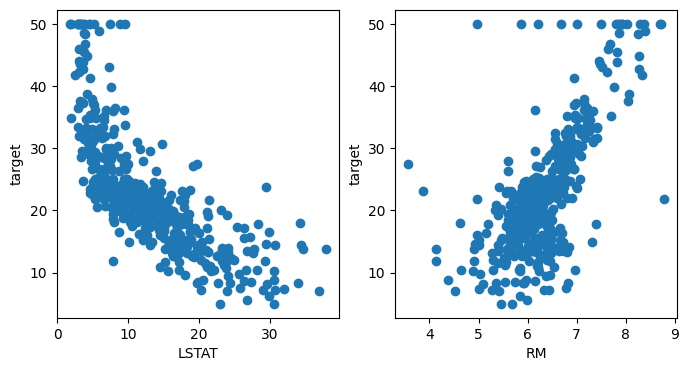

In [12]:
plt.figure(figsize=(8, 4))

features = df[["LSTAT", "RM"]]
target = df['target']

plt.subplot(1,2,1)
plt.scatter(features['LSTAT'], target)
plt.xlabel('LSTAT')
plt.ylabel('target')

plt.subplot(1,2,2)
plt.scatter(features['RM'], target)
plt.xlabel('RM')
plt.ylabel('target')

plt.show()

In [23]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=23)


In [14]:
from sklearn.linear_model import LinearRegression

In [24]:
model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)



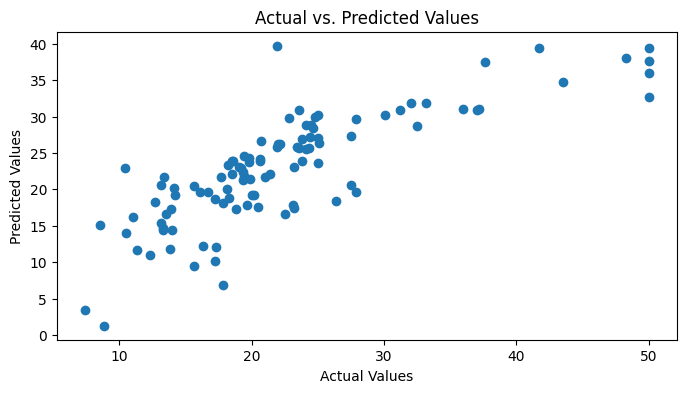

In [25]:
plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

In [26]:
intercept = model.intercept_
coefficients = model.coef_

print("Intercept:", intercept)
print("Coefficients:", coefficients)

Intercept: 0.37428615187841885
Coefficients: [-0.66721079  4.88331552]


In [27]:
mse = mean_squared_error(y_test, y_pred)
print("MSE: ", mse)

mae = mean_absolute_error(y_test, y_pred)
print("MAE: ", mae)

r2 = r2_score(y_test, y_pred)
print("R2: ", r2)

MSE:  30.726065211573893
MAE:  4.300122669036365
R2:  0.6433023932639312


In [28]:
new_houses = pd.DataFrame({'LSTAT': [5, 10, 15], 'RM': [6, 7, 8]})

In [29]:
new_pred = model.predict(new_houses)
print(new_pred)

[26.33812534 27.8853869  29.43264846]


In [30]:
new_houses['Predicted_Price'] = new_pred
new_houses

,LSTAT,RM,Predicted_Price
0,5,6,26.338125
1,10,7,27.885387
2,15,8,29.432648
